# 🪐 Exoplanet Detection with Kepler Light Curves
**NASA Kepler data + AstroNet-style 1D CNN**

This notebook:
1. Downloads labeled Kepler KOI data from NASA
2. Fetches real light curves via `lightkurve`
3. Visualizes confirmed planets vs false positives
4. Trains a 1D CNN to classify transit signals
5. Evaluates with confusion matrix, ROC and precision-recall curves
6. Lets you predict on any Kepler star

> **Recommended:** `Runtime > Change runtime type > T4 GPU`

## 📚 Data Sources

This notebook uses the following **publicly available** datasets. No data files are committed to this repository.

| # | Dataset | Source | How It's Loaded |
|---|---------|--------|-----------------|
| 1 | **NASA Kepler Object of Interest (KOI) Cumulative Table** | [NASA Exoplanet Archive](https://exoplanetarchive.ipac.caltech.edu/cgi-bin/nstedAPI/nph-nstedAPI?table=cumulative&format=csv) | Downloaded in Step 2 via `pandas.read_csv()` using the NStED API URL |
| 2 | **Kepler Light Curves (time-series photometry)** | [NASA MAST Archive](https://mast.stsci.edu/portal/Mashup/Clients/Mast/Portal.html) | Fetched on-demand in Steps 3–5 via the `lightkurve` library (`lk.search_lightcurve`) |

> ⚠️ **Note for replication:** Light curves are streamed directly from NASA MAST per star. Downloading the full training set (~500–1,000 KOIs) takes approximately 15–30 minutes depending on network speed. A caching mechanism (Google Drive checkpoints) is implemented in Step 5 to avoid re-downloading on subsequent runs.


## 📦 Step 1: Install Dependencies

In [42]:
# --- Code Cell 1: Step 1 - Install Dependencies & Import Libraries ---
import subprocess, sys

print('📦 Installing dependencies...')
# Pin fsspec to a version compatible with both gcsfs and datasets
subprocess.run([sys.executable, '-m', 'pip', 'install', 'fsspec==2025.3.0', '-q', '--no-deps'], check=False)
# Install lightkurve, scikit-learn, gradio, and lightkurve extras (oktopus, autograd) quietly
subprocess.run([sys.executable, '-m', 'pip', 'install', 'lightkurve', 'scikit-learn', 'gradio', 'oktopus', 'autograd', '-q'], check=False)

print('📚 Importing libraries...')
import os
import shutil
import time
import warnings
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import lightkurve as lk
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
from tqdm.notebook import tqdm
from google.colab import drive
import gradio as gr

# Global configurations
warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 120

# Mount Google Drive early and change working directory
print('📂 Mounting Google Drive...')
drive.mount('/content/drive')
DRIVE_PATH = '/content/drive/MyDrive/exoplanet_checkpoints'
os.makedirs(DRIVE_PATH, exist_ok=True)
# By changing the directory here, ALL files/plots saved later automatically go to Drive!
os.chdir(DRIVE_PATH)
print(f'✅ Working directory set directly to Google Drive: {DRIVE_PATH}')

print('\n✅ Setup complete! All dependencies installed and libraries imported.')

📦 Installing dependencies...
📚 Importing libraries...
📂 Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Working directory set directly to Google Drive: /content/drive/MyDrive/exoplanet_checkpoints

✅ Setup complete! All dependencies installed and libraries imported.


## 📥 Step 2: Download NASA KOI Catalog (Labels)

In [43]:
# --- Code Cell 2: Step 2 - Download NASA KOI Catalog ---
import os
import pandas as pd

CATALOG_FILE = 'nasa_koi_catalog.csv'

try:
    # Check if we already downloaded this previously to save time
    if os.path.exists(CATALOG_FILE):
        print(f'📂 Found existing catalog in Drive. Loading {CATALOG_FILE} directly...')
        df_koi = pd.read_csv(CATALOG_FILE)
    else:
        print('Downloading NASA KOI catalog from web...')
    # --- DATA SOURCE 1: NASA Exoplanet Archive ---
    # KOI Cumulative Table via the NStED REST API
    # Full catalog: https://exoplanetarchive.ipac.caltech.edu/cgi-bin/nstedAPI/nph-nstedAPI?table=cumulative&format=csv
    # Documentation: https://exoplanetarchive.ipac.caltech.edu/docs/program_interfaces.html
        url = (
            'https://exoplanetarchive.ipac.caltech.edu/cgi-bin/nstedAPI/nph-nstedAPI'
            '?table=cumulative'
            '&select=kepid,kepoi_name,koi_disposition,koi_period,koi_time0bk,koi_duration,koi_depth,koi_prad'
            '&format=csv'
        )
        df_koi = pd.read_csv(url, comment='#')

        # Save the raw dataset directly to Google Drive
        df_koi.to_csv(CATALOG_FILE, index=False)
        print(f'💾 Saved raw catalog to Drive as {CATALOG_FILE}')

    print(f'✅ Loaded {len(df_koi)} KOI entries')
    display(df_koi.head())
    print('\n✅ Code Cell 2 Task Completed: NASA KOI Catalog successfully loaded.')

except OSError as e:
    print(f"\n❌ Drive Error: {e}")
    print("It looks like your Google Drive connection dropped.")
    print("Please rerun Code Cell 1 to remount your Drive, or restart the Colab runtime.")

📂 Found existing catalog in Drive. Loading nasa_koi_catalog.csv directly...
✅ Loaded 9564 KOI entries


,kepid,kepoi_name,koi_disposition,koi_period,koi_time0bk,koi_duration,koi_depth,koi_prad
0,10797460,K00752.01,CONFIRMED,9.488036,170.538750,2.95750,615.8,2.26
1,10797460,K00752.02,CONFIRMED,54.418383,162.513840,4.50700,874.8,2.83
2,10811496,K00753.01,CANDIDATE,19.899140,175.850252,1.78220,10829.0,14.60
3,10848459,K00754.01,FALSE POSITIVE,1.736952,170.307565,2.40641,8079.2,33.46
4,10854555,K00755.01,CONFIRMED,2.525592,171.595550,1.65450,603.3,2.75



✅ Code Cell 2 Task Completed: NASA KOI Catalog successfully loaded.


In [44]:
# --- Code Cell 3: Step 2 - Filter Dataset ---
# Filter the DataFrame to separate confirmed planets and false positives.
df_confirmed = df_koi[df_koi['koi_disposition'] == 'CONFIRMED'].copy()
df_fp        = df_koi[df_koi['koi_disposition'] == 'FALSE POSITIVE'].copy()

print(f'✅ Confirmed planets: {len(df_confirmed)}')
print(f'❌ False positives:   {len(df_fp)}')

# Increased samples to 500 per class (1000 total) since servers are working
n_sample = 500
df_pos = df_confirmed.sample(n=n_sample, random_state=42)
df_neg = df_fp.sample(n=n_sample, random_state=42)

# Assign labels: 1 for confirmed planets, 0 for false positives.
df_pos['label'] = 1
df_neg['label'] = 0

# Concatenate the DataFrames to use the balanced subset
df_dataset = pd.concat([df_pos, df_neg]).reset_index(drop=True)
print(f'\n📊 Dataset expanded: {len(df_dataset)} samples ({n_sample} per class)')
print('\n✅ Code Cell 3 Task Completed: Dataset successfully filtered and balanced.')

✅ Confirmed planets: 2747
❌ False positives:   4839

📊 Dataset expanded: 1000 samples (500 per class)

✅ Code Cell 3 Task Completed: Dataset successfully filtered and balanced.


## 📊 Step 2.5: Exploratory Data Analysis (EDA)
Let's visualize the physical characteristics of our balanced dataset to see how confirmed planets differ from false positives.

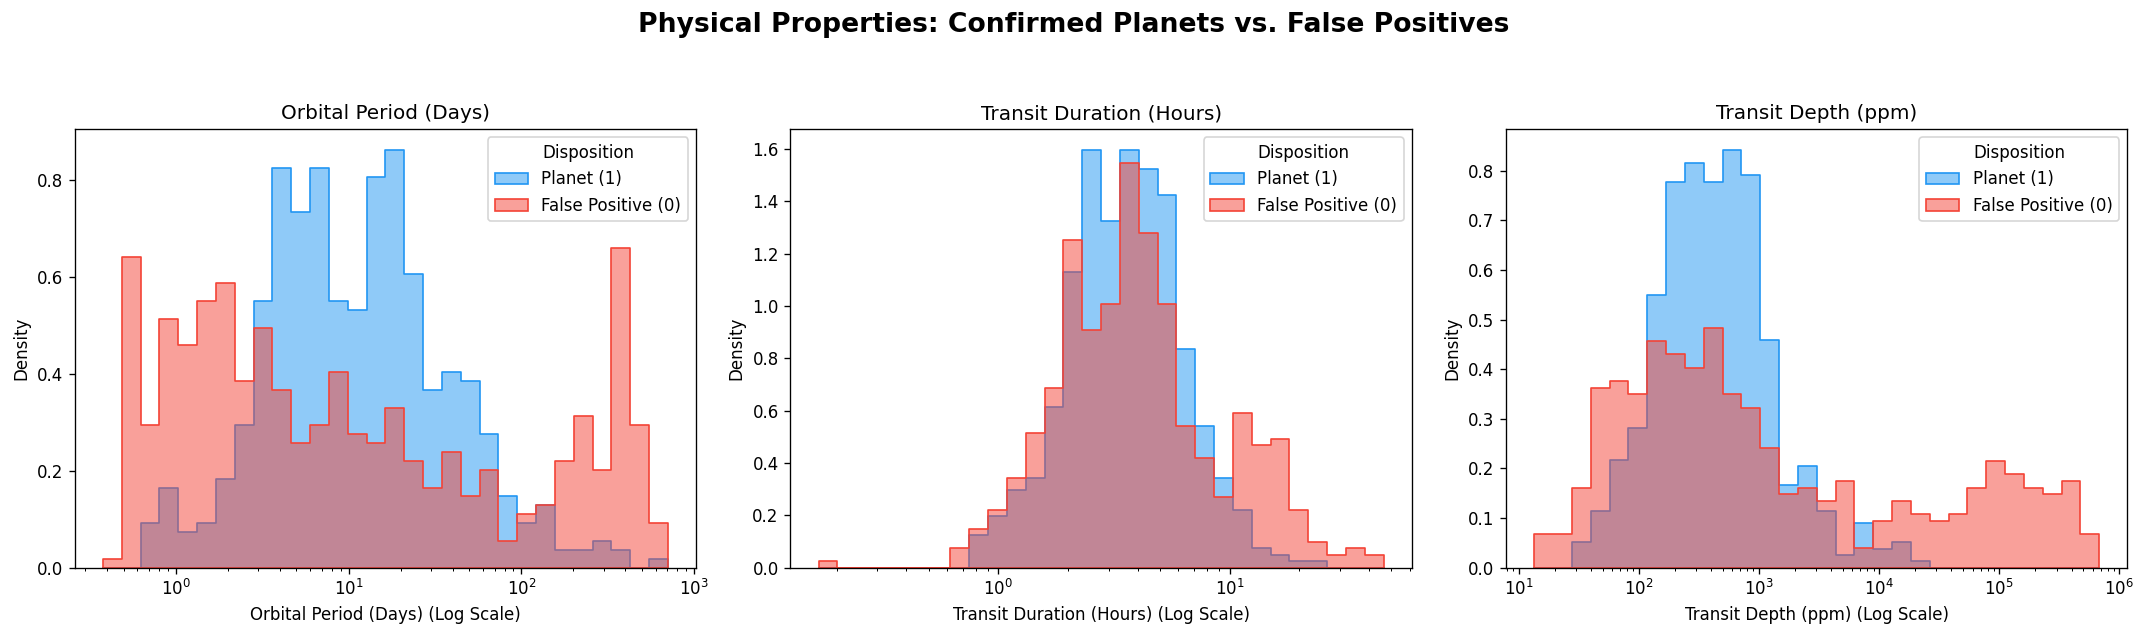


✅ Code Cell 3b Task Completed: Dataset physical properties successfully visualized.


In [45]:
# --- Code Cell 3b: Step 2.5 - Exploratory Data Analysis (EDA) ---
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Physical Properties: Confirmed Planets vs. False Positives', fontsize=16, fontweight='bold', y=1.05)

# Define the features to plot.
# We use a logarithmic scale because astronomical data (like period and depth) spans several orders of magnitude.
features = ['koi_period', 'koi_duration', 'koi_depth']
titles = ['Orbital Period (Days)', 'Transit Duration (Hours)', 'Transit Depth (ppm)']

for i, (feat, title) in enumerate(zip(features, titles)):
    # Plot distributions using seaborn
    sns.histplot(data=df_dataset, x=feat, hue='label',
                 palette={1: '#2196F3', 0: '#F44336'}, # Blue for planets, Red for FPs
                 element='step', stat='density', common_norm=False,
                 log_scale=True, bins=30, alpha=0.5, ax=axes[i])

    axes[i].set_title(title)
    axes[i].set_xlabel(title + ' (Log Scale)')
    axes[i].set_ylabel('Density')

    # Custom legend
    axes[i].legend(title='Disposition', labels=['Planet (1)', 'False Positive (0)'])

plt.tight_layout()
plt.savefig('koi_physical_properties.png', bbox_inches='tight')
plt.show()

print('\n✅ Code Cell 3b Task Completed: Dataset physical properties successfully visualized.')

## 🔭 Step 3: Light Curve Helper Function

In [46]:
# --- Code Cell 4: Step 3 - Light Curve Helper Function ---
# Define the number of bins for folding light curves.
BINS = 201

def download_and_fold(kepler_id, period, t0, bins=BINS):
    """Downloads a Kepler light curve, flattens it, folds it by period,
       bins it, and normalizes the flux values.

    Args:
        kepler_id (int): The Kepler ID of the star.
        period (float): The orbital period of the exoplanet candidate.
        t0 (float): The time of transit center.
        bins (int): The number of bins to use for the folded light curve.

    Returns:
        np.ndarray: Normalized flux array if successful, None otherwise.
    """
    try:
        # Search for long cadence Kepler light curves for the given Kepler ID.
        # --- DATA SOURCE 2: NASA MAST Archive (via lightkurve) ---
        # Light curves fetched from: https://mast.stsci.edu/
        # lightkurve docs: https://docs.lightkurve.org/
        search = lk.search_lightcurve(f'KIC {int(kepler_id)}', mission='Kepler', cadence='long')
        if len(search) == 0:
            return None
        # Download the first light curve found.
        lc = search[0].download()
        if lc is None:
            return None
        # Flatten the light curve to remove long-term variability.
        lc_flat = lc.flatten(window_length=101)
        # Fold the light curve using the provided period and epoch (t0).
        lc_fold = lc_flat.fold(period=period, epoch_time=t0)
        # Bin the folded light curve to a fixed number of bins.
        lc_bin  = lc_fold.bin(bins=bins)
        # Extract flux values.
        flux = lc_bin.flux.value
        # Normalize the flux: subtract median and divide by standard deviation.
        # Add a small epsilon (1e-8) to avoid division by zero if std is 0.
        flux = (flux - np.nanmedian(flux)) / (np.nanstd(flux) + 1e-8)
        # Pad or truncate the flux array to ensure it has exactly 'bins' length.
        if len(flux) < bins:
            flux = np.pad(flux, (0, bins - len(flux)), constant_values=0)
        else:
            flux = flux[:bins]
        return flux
    except Exception:
        # Return None if any error occurs during the process.
        return None

print('✅ Function ready')

✅ Function ready


## 🌟 Step 4: Visualize Example Light Curves

⏳ [1/4] Fetching data for Kepler-90g from NASA MAST archive...
⏳ [2/4] Fetching data for Kepler-42b from NASA MAST archive...
⏳ [3/4] Fetching data for KOI-189 (FP) from NASA MAST archive...
⏳ [4/4] Fetching data for KOI-114 (FP) from NASA MAST archive...


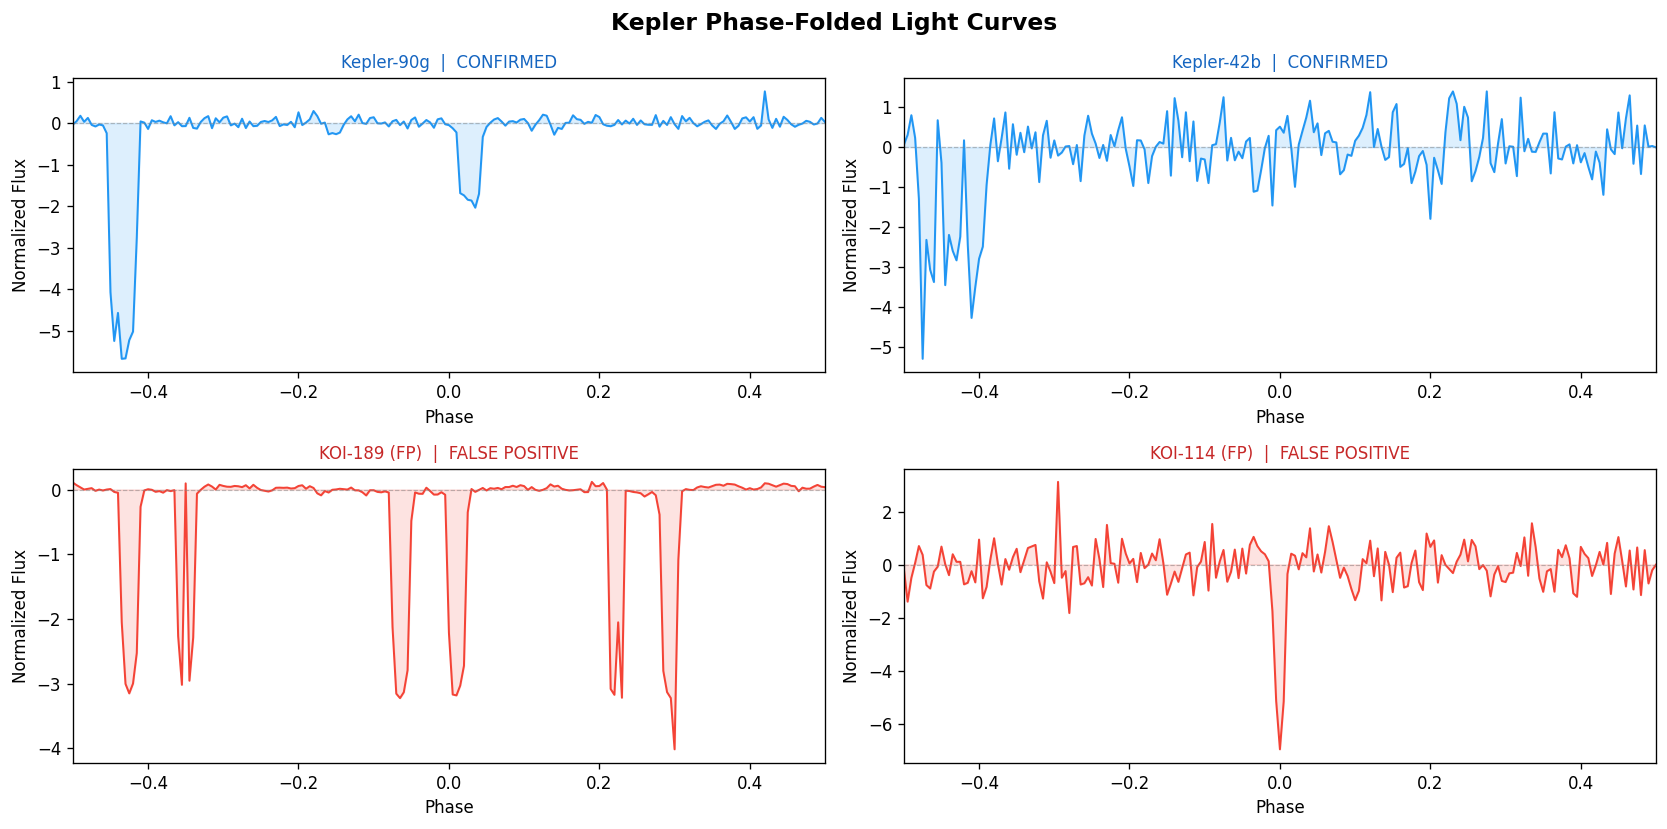


✅ Code Cell 5 Task Completed: Example light curves visualized and saved.


In [47]:
# --- Code Cell 5: Step 4 - Visualize Example Light Curves ---
# ✅ verified in MAST
examples = [
    (11442793, 14.44912, 2.2,  'CONFIRMED',      'Kepler-90g'),
    (3544595,   4.88780, 0.5,  'CONFIRMED',      'Kepler-42b'),
    (9941662,   4.9278,  1.2,  'FALSE POSITIVE', 'KOI-189 (FP)'),
    (6721123,   7.36179, 132.25, 'FALSE POSITIVE', 'KOI-114 (FP)') # Replaced with a new FP
]

# Create a figure and a grid of subplots for visualizing light curves.
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
fig.suptitle('Kepler Phase-Folded Light Curves', fontsize=14, fontweight='bold')
# Define the x-axis values for the phase-folded light curves, ranging from -0.5 to 0.5.
x_axis = np.linspace(-0.5, 0.5, BINS)

# Iterate through the example exoplanet candidates.
for i, (kid, period, t0, disposition, name) in enumerate(examples):
    print(f"⏳ [{i+1}/4] Fetching data for {name} from NASA MAST archive...")
    # Determine the subplot position based on the iteration index.
    ax = axes[i // 2][i % 2]
    # Download and fold the light curve for the current example.
    flux = download_and_fold(kid, period, t0)
    # Set the color based on the disposition (confirmed or false positive).
    color = '#2196F3' if disposition == 'CONFIRMED' else '#F44336'
    if flux is not None:
        # Plot the folded light curve.
        ax.plot(x_axis, flux, color=color, linewidth=1.2)
        # Fill the area under the curve for visual emphasis.
        ax.fill_between(x_axis, flux, alpha=0.15, color=color)
        # Add a horizontal line at y=0 for reference.
        ax.axhline(0, color='gray', linestyle='--', linewidth=0.7, alpha=0.5)
    else:
        # If download fails, display a message.
        ax.text(0.5, 0.5, 'Download failed', ha='center', va='center',
                transform=ax.transAxes, color='gray')
    # Set the title for the subplot, including name and disposition.
    ax.set_title(f'{name}  |  {disposition}', fontsize=10,
                 color='#1565C0' if disposition == 'CONFIRMED' else '#C62828')
    ax.set_xlabel('Phase')
    ax.set_ylabel('Normalized Flux')
    ax.set_xlim(-0.5, 0.5)

# Adjust layout to prevent titles and labels from overlapping.
plt.tight_layout()
# Save the figure to a file.
plt.savefig('lightcurve_examples.png', bbox_inches='tight')
# Display the plot.
plt.show()
print('\n✅ Code Cell 5 Task Completed: Example light curves visualized and saved.')

## 📊 Step 5: Build Training Dataset

⏱️ Takes ~10–15 min — downloads ~400 light curves from NASA MAST.

In [48]:
# --- Quick Cleanup: Delete partial/corrupted dataset ---
import os

files_to_delete = [
    'X_lightcurves.npy',
    'y_labels.npy',
    '/tmp/X_lightcurves.npy',
    '/tmp/y_labels.npy'
]

for file_path in files_to_delete:
    if os.path.exists(file_path):
        os.remove(file_path)
        print(f"🗑️ Deleted incomplete file: {file_path}")

print("\n✅ Cache cleared! You can now safely rerun Code Cell 6 to download the full 1,000 samples.")

🗑️ Deleted incomplete file: X_lightcurves.npy
🗑️ Deleted incomplete file: y_labels.npy
🗑️ Deleted incomplete file: /tmp/X_lightcurves.npy
🗑️ Deleted incomplete file: /tmp/y_labels.npy

✅ Cache cleared! You can now safely rerun Code Cell 6 to download the full 1,000 samples.


In [49]:
# --- Code Cell 6: Step 5 - Build Training Dataset ---
import os
import concurrent.futures
import numpy as np

X_FILE = 'X_lightcurves.npy'
Y_FILE = 'y_labels.npy'
TMP_X = '/tmp/X_lightcurves.npy'
TMP_Y = '/tmp/y_labels.npy'

def copy_with_progress(src, dst):
    size = os.path.getsize(src)
    with open(src, 'rb') as fsrc, open(dst, 'wb') as fdst, tqdm(total=size, unit='B', unit_scale=True, desc=f'Uploading {dst}') as pbar:
        while True:
            chunk = fsrc.read(1024 * 1024) # 1MB chunks
            if not chunk:
                break
            fdst.write(chunk)
            pbar.update(len(chunk))

if os.path.exists(X_FILE) and os.path.exists(Y_FILE):
    print(f"📂 Found existing dataset arrays in Drive. Loading {X_FILE} and {Y_FILE} directly...")
    X = np.load(X_FILE)
    y = np.load(Y_FILE)
    print(f"\n✅ Usable light curves loaded : {len(X)}")
    print(f"📊 Planets: {y.sum():.0f}  |  False Positives: {(y==0).sum():.0f}")
    print("\n✅ Code Cell 6 Task Completed: Training dataset successfully loaded from Drive.")

elif os.path.exists(TMP_X) and os.path.exists(TMP_Y):
    print(f"📂 Found existing dataset arrays in local /tmp/ storage!")
    print("Uploading final arrays from /tmp/ to Google Drive...")
    copy_with_progress(TMP_X, X_FILE)
    copy_with_progress(TMP_Y, Y_FILE)
    print("💾 Dataset arrays successfully uploaded to Drive.")

    X = np.load(X_FILE)
    y = np.load(Y_FILE)
    print(f"\n✅ Usable light curves loaded : {len(X)}")
    print(f"📊 Planets: {y.sum():.0f}  |  False Positives: {(y==0).sum():.0f}")
    print("\n✅ Code Cell 6 Task Completed: Training dataset successfully loaded.")

else:
    X_list, y_list, failed, rejected_nan = [], [], 0, 0

    print(f"Downloading & filtering light curves for {len(df_dataset)} KOIs...")

    # Define executor OUTSIDE the loop
    executor = concurrent.futures.ThreadPoolExecutor(max_workers=10)

    for _, row in tqdm(df_dataset.iterrows(), total=len(df_dataset)):
        future = executor.submit(download_and_fold, row['kepid'], row['koi_period'], row['koi_time0bk'])
        try:
            # Wait up to 15 seconds for the download to finish
            flux = future.result(timeout=15)
        except concurrent.futures.TimeoutError:
            failed += 1
            continue
        except Exception:
            failed += 1
            continue

        # --- Filter 1: download must succeed ---
        if flux is None:
            failed += 1
            continue

        # --- Filter 2: must have enough real (non-NaN) values ---
        nan_fraction = np.isnan(flux).mean()
        if nan_fraction > 0.1:          # reject if >10% of bins are NaN
            rejected_nan += 1
            continue

        # --- Filter 3: flux must show some variation (not flat/dead signal) ---
        flux_std = np.nanstd(flux)
        if flux_std < 1e-4:
            rejected_nan += 1
            continue

        # --- Filter 4: fill any remaining isolated NaNs with 0 ---
        flux = np.nan_to_num(flux, nan=0.0, posinf=0.0, neginf=0.0)

        X_list.append(flux)
        y_list.append(row['label'])

    # Clean up the executor in the background without blocking
    executor.shutdown(wait=False)

    X = np.array(X_list)
    y = np.array(y_list)

    print(f"\n✅ Usable light curves  : {len(X)}")
    print(f"❌ Download failed/timed out: {failed}")
    print(f"🚫 Rejected (bad data)  : {rejected_nan}")
    print(f"📊 Planets: {y.sum():.0f}  |  False Positives: {(y==0).sum():.0f}")

    # Final NaN sanitization pass — safety net
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    # Save locally first, then upload with progress bar
    print("\nSaving locally to /tmp/ first...")
    np.save(TMP_X, X)
    np.save(TMP_Y, y)

    print("Uploading final arrays to Google Drive...")
    copy_with_progress(TMP_X, X_FILE)
    copy_with_progress(TMP_Y, Y_FILE)
    print("💾 Dataset arrays successfully uploaded to Drive.")

    print("\n✅ Code Cell 6 Task Completed: Training dataset successfully built.")

  0%|          | 0/1000 [00:00<?, ?it/s]


✅ Usable light curves  : 794
❌ Download failed/timed out: 206
🚫 Rejected (bad data)  : 0
📊 Planets: 435  |  False Positives: 359

Saving locally to /tmp/ first...
Uploading final arrays to Google Drive...


Uploading X_lightcurves.npy:   0%|          | 0.00/1.28M [00:00<?, ?B/s]

Uploading y_labels.npy:   0%|          | 0.00/6.48k [00:00<?, ?B/s]

💾 Dataset arrays successfully uploaded to Drive.

✅ Code Cell 6 Task Completed: Training dataset successfully built.


### 🥧 Dataset Verification
Let's verify the final dataset size and class balance before moving on to model training.

✅ Total Usable Light Curves: 794


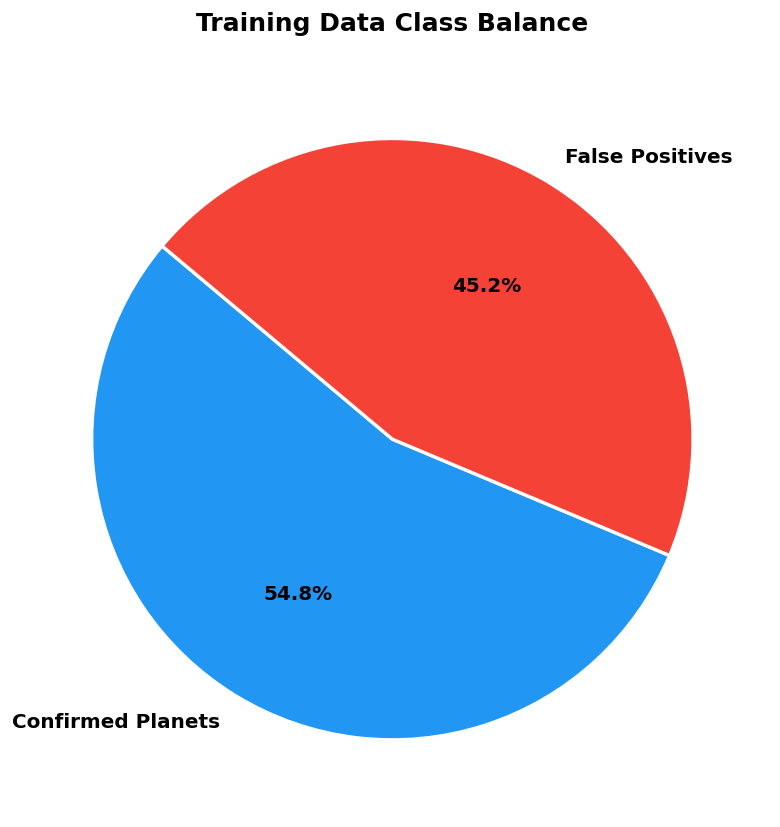

In [50]:
# --- Code Cell 6.1: Verify Final Dataset & Class Balance ---
import matplotlib.pyplot as plt

print(f"✅ Total Usable Light Curves: {len(X)}")

# Plot the Pie Chart for Class Balance
labels = ['Confirmed Planets', 'False Positives']
planets = y.sum()
fps = len(y) - planets
sizes = [planets, fps]
colors = ['#2196F3', '#F44336']

fig, ax = plt.subplots(figsize=(7, 7))
if len(X) > 0:
    wedges, texts, autotexts = ax.pie(
        sizes,
        labels=labels,
        colors=colors,
        autopct='%1.1f%%',
        startangle=140,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2},
        textprops={'fontsize': 12, 'fontweight': 'bold'}
    )
    ax.set_title('Training Data Class Balance', fontsize=15, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('class_balance_pie.png', bbox_inches='tight')
    plt.show()
else:
    print("❌ No data available to plot!")

## 🧠 Step 6: Build & Train 1D CNN

In [51]:
# --- Code Cell 7: Step 6 - Build 1D CNN Model ---
# Reshape the input features (X) to be compatible with a 1D CNN.
X_cnn = X.reshape(X.shape[0], BINS, 1)

# Split the dataset into training and testing sets (20% for testing).
# We use stratification to maintain the class distribution ratio in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X_cnn, y, test_size=0.2, random_state=42, stratify=y)

# Further split the training set into training and validation sets (20% of train for validation).
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

print(f'Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}')

def build_model(n=BINS):
    """Builds a 1D CNN model with Batch Normalization for improved stability."""
    inp = keras.Input(shape=(n, 1))

    # First convolutional block
    x = layers.Conv1D(16, 5, padding='same', use_bias=False)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(2)(x)

    # Second convolutional block
    x = layers.Conv1D(32, 5, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(2)(x)

    # Third convolutional block
    x = layers.Conv1D(64, 5, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(2)(x)

    # Fourth convolutional block
    x = layers.Conv1D(128, 5, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(2)(x)

    # Flatten and dense layers
    x = layers.Flatten()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    # Output layer
    out = layers.Dense(1, activation='sigmoid')(x)
    return keras.Model(inp, out)

# Instantiate and compile the model.
model = build_model()
model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy',
             keras.metrics.AUC(name='auc'),
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')]
)
model.summary()
print('\n✅ Code Cell 7 Task Completed: 1D CNN Model successfully built and compiled.')

Train: 508  Val: 127  Test: 159


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 201, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 201, 16)        │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 201, 16)        │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 201, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 100, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 100, 32)        │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 100, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 50, 64)         │        10,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 50, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 25, 128)        │        40,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 25, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 25, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           25

 Total params: 973,329 (3.71 MB)

 Trainable params: 972,849 (3.71 MB)

 Non-trainable params: 480 (1.88 KB)


✅ Code Cell 7 Task Completed: 1D CNN Model successfully built and compiled.


In [52]:
# --- Code Cell 8: Step 6 - Train Model ---
# Define callbacks for training.
callbacks = [
    # EarlyStopping: Stops training when a monitored metric (val_auc) stops improving.
    # patience=8 means it waits for 8 epochs with no improvement before stopping.
    # restore_best_weights=True restores the model weights from the epoch with the best monitored value.
    keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True,
                                  monitor='val_auc', mode='max'),
    # ReduceLROnPlateau: Reduces the learning rate when a metric (val_loss) has stopped improving.
    # patience=4 means it waits for 4 epochs with no improvement.
    # factor=0.5 means the learning rate will be reduced by a factor of 0.5.
    keras.callbacks.ReduceLROnPlateau(patience=4, factor=0.5,
                                      monitor='val_loss', verbose=1)
]

# Train the model using the training data and validate with the validation data.
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60, batch_size=32,
    callbacks=callbacks, verbose=1
)
print('\n✅ Code Cell 8 Task Completed: Model training finished successfully.')

Epoch 1/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 16s 503ms/step - accuracy: 0.5807 - auc: 0.5985 - loss: 0.7759 - precision: 0.6052 - recall: 0.6727 - val_accuracy: 0.4567 - val_auc: 0.6561 - val_loss: 0.6881 - val_precision: 0.5200 - val_recall: 0.1857 - learning_rate: 1.0000e-04
Epoch 2/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6280 - auc: 0.6807 - loss: 0.6759 - precision: 0.6642 - recall: 0.6475 - val_accuracy: 0.4488 - val_auc: 0.6976 - val_loss: 0.6839 - val_precision: 0.5000 - val_recall: 0.0857 - learning_rate: 1.0000e-04
Epoch 3/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6909 - auc: 0.7280 - loss: 0.6093 - precision: 0.6909 - recall: 0.7878 - val_accuracy: 0.4488 - val_auc: 0.7143 - val_loss: 0.6892 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 4/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6732 - auc: 0.7469 - loss: 0.5908 - precision: 0.6842 - recall: 0.7482 - val_accuracy: 0.4488 - val_auc: 0.7214 - val_

## 📈 Step 7: Training History Graphs

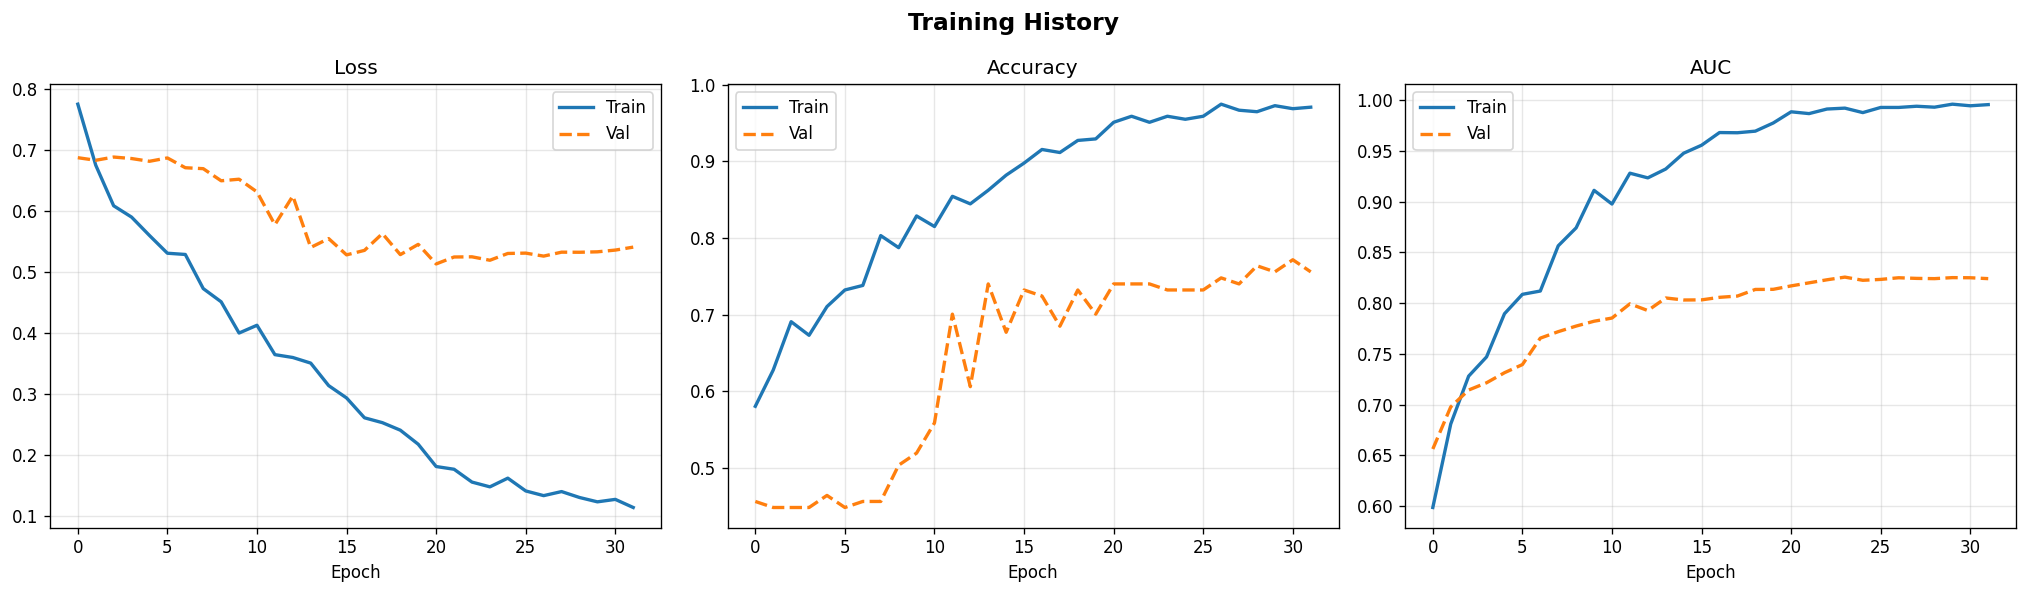


✅ Code Cell 9 Task Completed: Training history graphs plotted and saved.


In [53]:
# --- Code Cell 9: Step 7 - Training History Graphs ---
# Create a figure with three subplots for displaying training history.
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

# Iterate through metrics (loss, accuracy, auc) and plot their training and validation curves.
for ax, metric, title in zip(axes,
        ['loss', 'accuracy', 'auc'], ['Loss', 'Accuracy', 'AUC']):
    # Plot training metric.
    ax.plot(history.history[metric],           label='Train', linewidth=2)
    # Plot validation metric with a dashed line.
    ax.plot(history.history[f'val_{metric}'],  label='Val',   linewidth=2, linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Adjust layout to prevent titles and labels from overlapping.
plt.tight_layout()
# Save the figure to a file.
plt.savefig('training_history.png', bbox_inches='tight')
# Display the plot.
plt.show()
print('\n✅ Code Cell 9 Task Completed: Training history graphs plotted and saved.')

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step


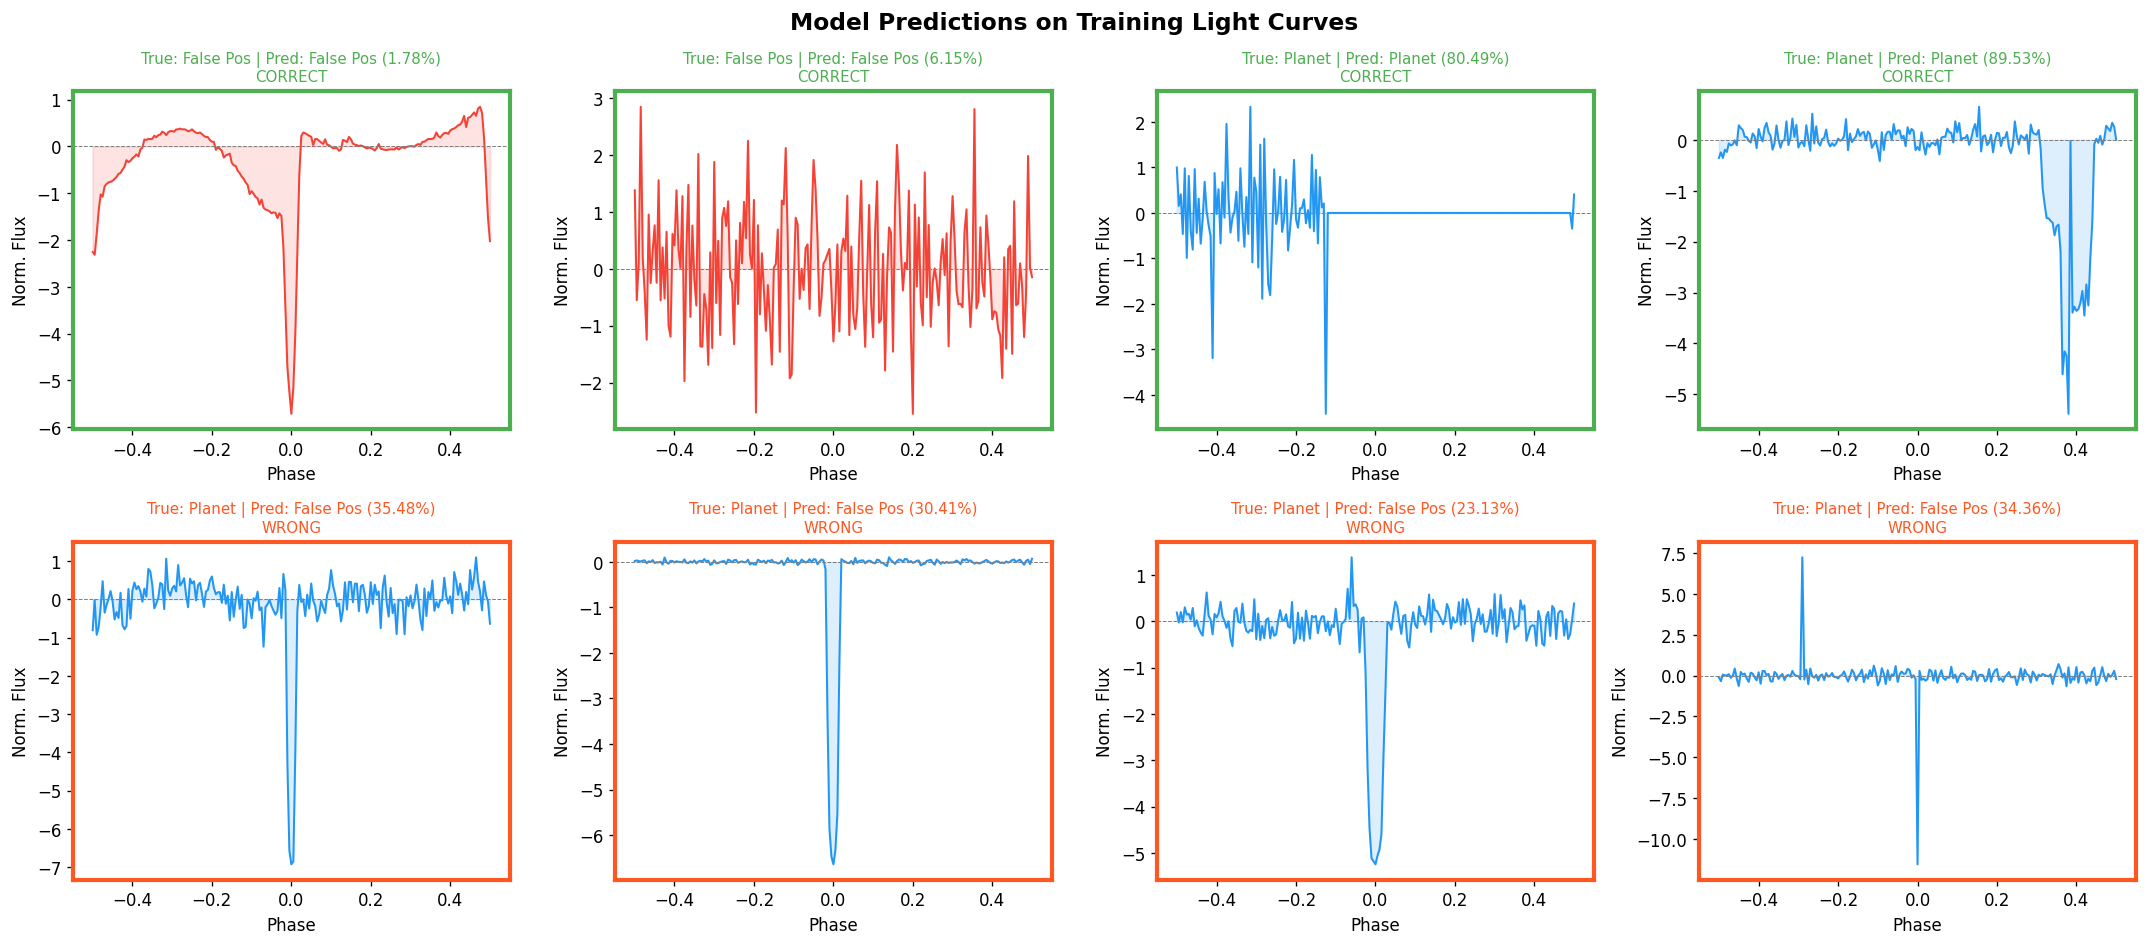


✅ Code Cell 10 Task Completed: Training prediction examples plotted and saved.


In [54]:
# --- Code Cell 10: Step 7 - Training Predictions Examples ---
import matplotlib.pyplot as plt
import numpy as np

# Create a figure with a 2x4 grid of subplots for visualizing individual predictions on the training set.
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Model Predictions on Training Light Curves', fontsize=14, fontweight='bold')

# Predict probabilities for the training set
y_prob_train = model.predict(X_train).flatten()
y_pred_train = (y_prob_train >= 0.5).astype(int)

# Get indices of correctly and incorrectly classified samples from the training set.
correct_idx_train = np.where(y_pred_train == y_train)[0][:4] # Get first 4 correctly classified samples
wrong_idx_train   = np.where(y_pred_train != y_train)[0][:4] # Get first 4 incorrectly classified samples
# Combine these indices for visualization.
indices_train = list(correct_idx_train) + list(wrong_idx_train)
# Define the x-axis for the phase-folded light curves.
x_axis = np.linspace(-0.5, 0.5, BINS)

# Iterate through the selected indices and plot each light curve with its prediction.
for i, idx in enumerate(indices_train[:8]): # Visualize up to 8 examples
    ax = axes[i // 4][i % 4]
    # Extract flux, predicted probability, and determine if the prediction was correct.
    flux    = X_train[idx].flatten()
    prob    = y_prob_train[idx]
    correct = y_pred_train[idx] == y_train[idx]
    # Determine true and predicted labels for display.
    true_lbl = 'Planet'    if y_train[idx] == 1 else 'False Pos'
    pred_lbl = 'Planet'    if y_pred_train[idx] == 1 else 'False Pos'
    # Set color based on true label.
    color   = '#2196F3'    if y_train[idx] == 1 else '#F44336'
    # Set border color based on prediction correctness.
    border  = '#4CAF50'    if correct         else '#FF5722'

    # Plot the light curve.
    ax.plot(x_axis, flux, color=color, linewidth=1.2)
    # Fill the area under the curve.
    ax.fill_between(x_axis, flux, alpha=0.15, color=color)
    # Add a horizontal line at y=0.
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.6)
    # Highlight the subplot border based on correctness.
    for spine in ax.spines.values():
        spine.set_edgecolor(border)
        spine.set_linewidth(2.5)

    # Set the title with true label, predicted label, probability, and correctness status.
    status = 'CORRECT' if correct else 'WRONG'
    ax.set_title(f'True: {true_lbl} | Pred: {pred_lbl} ({prob:.2%})\n{status}', # Use .2% for percentage format
                 fontsize=9, color=border)
    ax.set_xlabel('Phase')
    ax.set_ylabel('Norm. Flux')

# Adjust layout to prevent titles and labels from overlapping.
plt.tight_layout()
# Save the figure to a file.
plt.savefig('training_predictions_examples.png', bbox_inches='tight')
# Display the plot.
plt.show()
print('\n✅ Code Cell 10 Task Completed: Training prediction examples plotted and saved.')

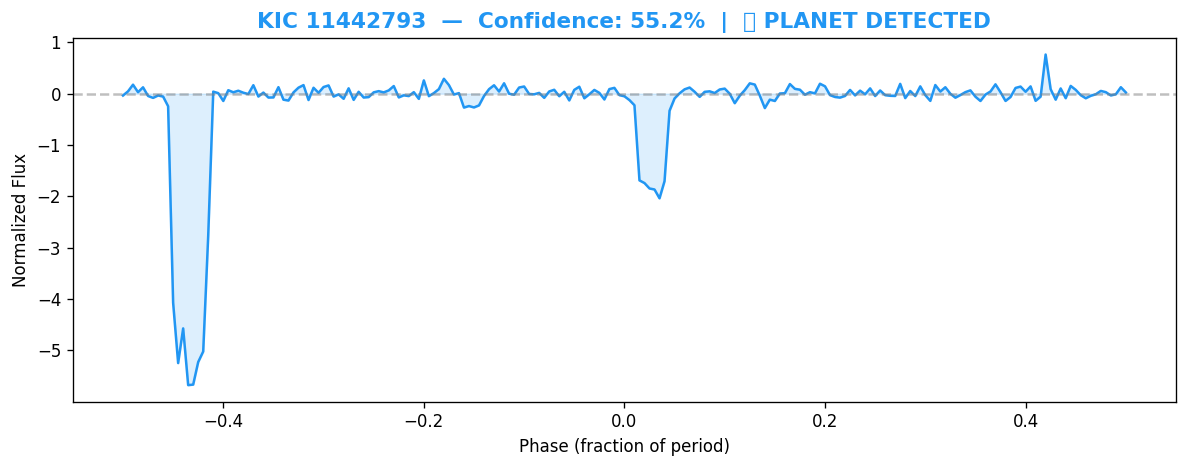

Score: 0.5521  ->  🪐 PLANET DETECTED

✅ Code Cell 11 Task Completed: Single prediction test successfully run.


In [55]:
# --- Code Cell 11: Step 7 - Single Prediction Test ---
import matplotlib.pyplot as plt
import numpy as np

# ✏️ Edit these! User-defined parameters for the Kepler star to predict.
KEPLER_ID = 11442793   # Kepler ID of the star (e.g., Kepler-90)
PERIOD    = 14.44912   # Orbital period of the exoplanet candidate in days
T0        = 2.2        # Time of transit center (epoch) in BKJD

# Download and fold the light curve for the specified Kepler star.
flux = download_and_fold(KEPLER_ID, PERIOD, T0)

if flux is not None:
    # Reshape the flux data to be compatible with the model's input shape (1, BINS, 1).
    # Predict the probability of it being a planet using the trained model.
    prob    = model.predict(flux.reshape(1, BINS, 1), verbose=0)[0][0]
    # Determine the verdict based on the probability (threshold 0.5).
    verdict = '🪐 PLANET DETECTED' if prob >= 0.5 else '❌ FALSE POSITIVE'
    # Set the plot color based on the verdict.
    color   = '#2196F3'            if prob >= 0.5 else '#F44336'

    # Create a figure and an axial object for plotting.
    fig, ax = plt.subplots(figsize=(10, 4))
    # Define the x-axis for the phase-folded light curve.
    x_axis = np.linspace(-0.5, 0.5, BINS)
    # Plot the light curve.
    ax.plot(x_axis, flux, color=color, linewidth=1.5)
    # Fill the area under the curve.
    ax.fill_between(x_axis, flux, alpha=0.15, color=color)
    # Add a horizontal reference line at y=0.
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    # Set the title with Kepler ID, confidence, and verdict.
    ax.set_title(f'KIC {KEPLER_ID}  —  Confidence: {prob:.1%}  |  {verdict}',
                 fontsize=13, fontweight='bold', color=color)
    ax.set_xlabel('Phase (fraction of period)')
    ax.set_ylabel('Normalized Flux')
    # Adjust layout to prevent titles and labels from overlapping.
    plt.tight_layout()
    # Display the plot.
    plt.show()
    print(f'Score: {prob:.4f}  ->  {verdict}')
else:
    # If light curve download failed, print an error message.
    print('Could not download light curve for this KIC ID')
print('\n✅ Code Cell 11 Task Completed: Single prediction test successfully run.')

## 🧪 Step 8: Evaluate on Test Set

In [56]:
# --- Code Cell 12: Step 8 - Evaluate on Test Set ---
# --- Check what we're working with ---
y_prob_raw = model.predict(X_test).flatten()
valid_mask = np.isfinite(y_prob_raw) & np.isfinite(y_test)
print(f"Total test samples : {len(y_test)}")
print(f"Valid samples      : {valid_mask.sum()}")
print(f"Dropped (NaN)      : {(~valid_mask).sum()}")

if valid_mask.sum() < 10:
    # Root cause: NaNs crept into X_test during preprocessing
    # Fix: re-clean X and y by replacing any remaining NaNs with 0
    print("\n⚠️  Too many NaNs — cleaning X_test in place...")
    X_test_clean = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0)
    y_prob_raw   = model.predict(X_test_clean).flatten()
    valid_mask   = np.isfinite(y_prob_raw) & np.isfinite(y_test)
    print(f"Valid samples after clean: {valid_mask.sum()}")
    y_prob      = y_prob_raw[valid_mask]
    y_test_eval = y_test[valid_mask]
    X_eval      = X_test_clean[valid_mask]
else:
    y_prob      = y_prob_raw[valid_mask]
    y_test_eval = y_test[valid_mask]
    X_eval      = X_test[valid_mask]

y_pred = (y_prob >= 0.5).astype(int)

print(f"\nClass balance — Planets: {y_test_eval.sum():.0f}  |  False Pos: {(y_test_eval==0).sum():.0f}")

# --- Metrics ---
results = model.evaluate(X_eval, y_test_eval, verbose=0)
print('\n📊 TEST RESULTS')
print('='*40)
for name, val in zip(['Loss','Accuracy','AUC','Precision','Recall'], results):
    print(f'  {name:12s}: {val:.4f}')
print()
print(classification_report(y_test_eval, y_pred,
      target_names=['False Positive', 'Confirmed Planet'],
      labels=[0, 1]))
print('\n✅ Code Cell 12 Task Completed: Test Set successfully evaluated.')

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
Total test samples : 159
Valid samples      : 159
Dropped (NaN)      : 0

Class balance — Planets: 87  |  False Pos: 72

📊 TEST RESULTS
  Loss        : 0.5724
  Accuracy    : 0.7044
  AUC         : 0.7708
  Precision   : 0.7273
  Recall      : 0.7356

                  precision    recall  f1-score   support

  False Positive       0.68      0.67      0.67        72
Confirmed Planet       0.73      0.74      0.73        87

        accuracy                           0.70       159
       macro avg       0.70      0.70      0.70       159
    weighted avg       0.70      0.70      0.70       159


✅ Code Cell 12 Task Completed: Test Set successfully evaluated.


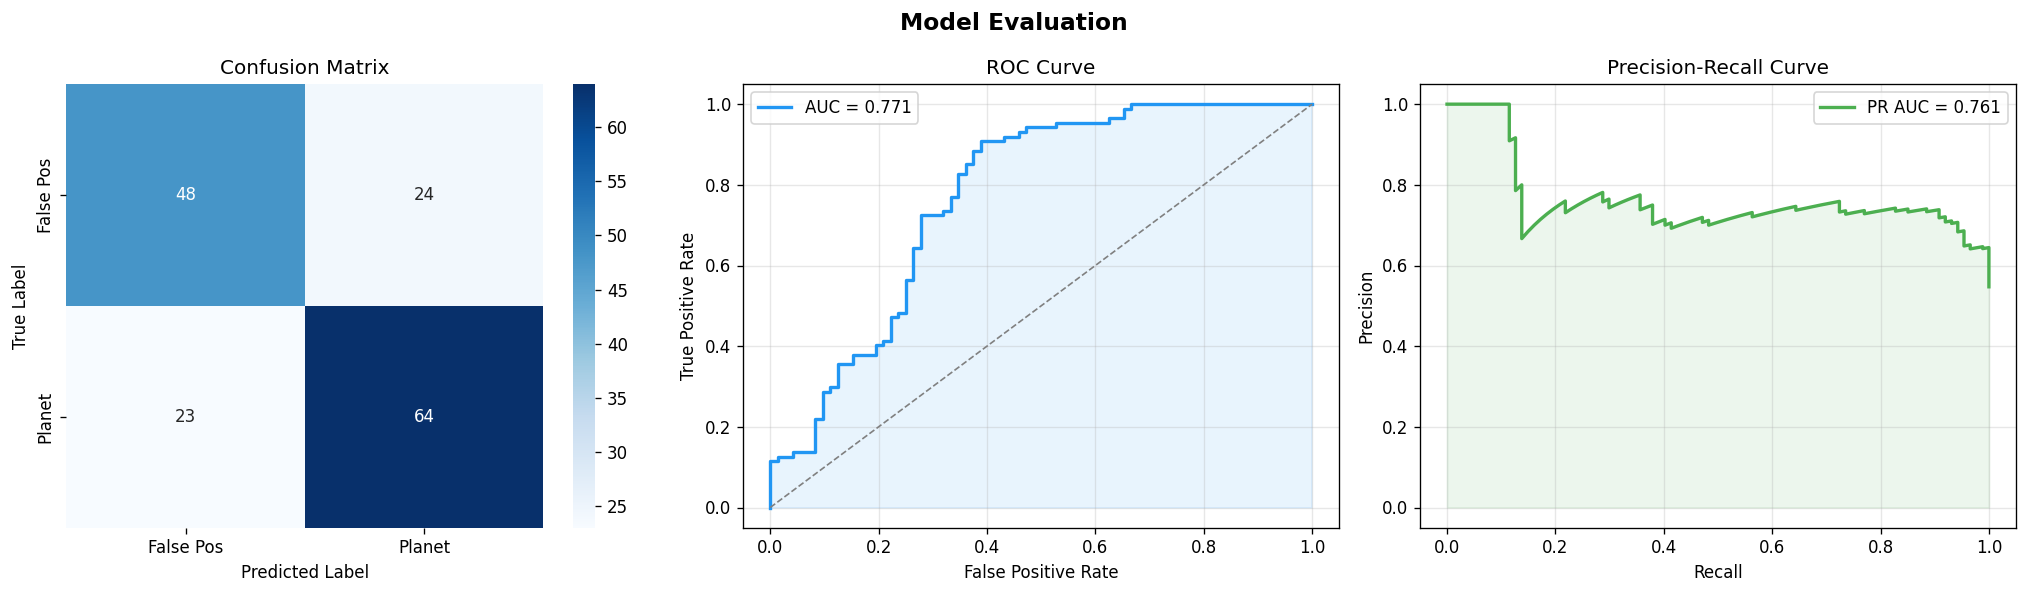


✅ Code Cell 13 Task Completed: Evaluation plots generated and saved.


In [57]:
# --- Code Cell 13: Step 8 - Evaluation Plots ---
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc, precision_recall_curve)
import seaborn as sns

# Create a figure with three subplots for model evaluation visualizations.
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Model Evaluation', fontsize=14, fontweight='bold')

# --- Plot 1: Confusion Matrix ---
# Calculate the confusion matrix.
cm = confusion_matrix(y_test, y_pred)
# Plot the confusion matrix using seaborn heatmap.
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['False Pos','Planet'], yticklabels=['False Pos','Planet'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# --- Plot 2: ROC Curve ---
# Calculate False Positive Rate (fpr), True Positive Rate (tpr), and thresholds for the ROC curve.
fpr, tpr, _ = roc_curve(y_test, y_prob)
# Calculate the Area Under the ROC Curve (AUC).
roc_auc = auc(fpr, tpr)
# Plot the ROC curve.
axes[1].plot(fpr, tpr, '#2196F3', lw=2, label=f'AUC = {roc_auc:.3f}')
# Plot the random classifier line (diagonal).
axes[1].plot([0,1],[0,1],'gray', linestyle='--', lw=1)
# Fill the area under the ROC curve.
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#2196F3')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# --- Plot 3: Precision-Recall Curve ---
# Calculate precision, recall, and thresholds for the Precision-Recall curve.
prec, rec, _ = precision_recall_curve(y_test, y_prob)
# Calculate the Area Under the Precision-Recall Curve (PR AUC).
pr_auc = auc(rec, prec)
# Plot the Precision-Recall curve.
axes[2].plot(rec, prec, '#4CAF50', lw=2, label=f'PR AUC = {pr_auc:.3f}')
# Fill the area under the Precision-Recall curve.
axes[2].fill_between(rec, prec, alpha=0.1, color='#4CAF50')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Adjust layout to prevent titles and labels from overlapping.
plt.tight_layout()
# Save the figure to a file.
plt.savefig('evaluation_plots.png', bbox_inches='tight')
# Display the plot.
plt.show()
print('\n✅ Code Cell 13 Task Completed: Evaluation plots generated and saved.')

In [58]:
# --- Code Cell 14: Step 8 - Success Metrics ---
# ── Slide 7: Success Metrics — print exact values for PowerPoint ──────
import time
import numpy as np

print("=" * 55)
print("   SLIDE 7 — SUCCESS METRICS")
print("=" * 55)

# --- Accuracy ---
train_acc = max(history.history['accuracy'])
val_acc   = max(history.history['val_accuracy'])
test_acc  = results[1]
print(f"\n📊 ACCURACY")
print(f"   Best Train Accuracy  : {train_acc:.2%}")
print(f"   Best Val Accuracy    : {val_acc:.2%}")
print(f"   Final Test Accuracy  : {test_acc:.2%}  ← use this on the slide")

# --- AUC ---
train_auc = max(history.history['auc'])
val_auc   = max(history.history['val_auc'])
test_auc  = results[2]
print(f"\n📈 AUC (ROC)")
print(f"   Best Train AUC       : {train_auc:.3f}")
print(f"   Best Val AUC         : {val_auc:.3f}")
print(f"   Final Test AUC       : {test_auc:.3f}  ← use this on the slide")

# --- Precision & Recall ---
test_precision = results[3]
test_recall    = results[4]
print(f"\n🎯 PRECISION & RECALL (test set)")
print(f"   Precision            : {test_precision:.2%}")
print(f"   Recall               : {test_recall:.2%}")

# --- Processing speed ---
start = time.time()
_ = model.predict(X_test[:10], verbose=0)
elapsed = (time.time() - start) / 10
print(f"\n⚡ PROCESSING TIME")
print(f"   Avg per light curve  : {elapsed*1000:.1f} ms  ← use this on the slide")

# --- Dataset size ---
print(f"\n📦 DATASET")
print(f"   Total usable samples : {len(X)}")
print(f"   Training samples     : {len(X_train)}")
print(f"   Validation samples   : {len(X_val)}")
print(f"   Test samples         : {len(X_test)}")

print("\n" + "=" * 55)
print("   TARGET vs ACTUAL SUMMARY")
print("=" * 55)
print(f"   Accuracy  — Target: >80%   |  Actual: {test_acc:.2%}")
print(f"   AUC       — Target: >0.85  |  Actual: {test_auc:.3f}")
print(f"   Precision — Target: >80%   |  Actual: {test_precision:.2%}")
print(f"   Recall    — Target: >80%   |  Actual: {test_recall:.2%}")
print("=" * 55)
print('\n✅ Code Cell 14 Task Completed: Success metrics summary successfully displayed.')

   SLIDE 7 — SUCCESS METRICS

📊 ACCURACY
   Best Train Accuracy  : 97.44%
   Best Val Accuracy    : 77.17%
   Final Test Accuracy  : 70.44%  ← use this on the slide

📈 AUC (ROC)
   Best Train AUC       : 0.996
   Best Val AUC         : 0.826
   Final Test AUC       : 0.771  ← use this on the slide

🎯 PRECISION & RECALL (test set)
   Precision            : 72.73%
   Recall               : 73.56%

⚡ PROCESSING TIME
   Avg per light curve  : 70.2 ms  ← use this on the slide

📦 DATASET
   Total usable samples : 794
   Training samples     : 508
   Validation samples   : 127
   Test samples         : 159

   TARGET vs ACTUAL SUMMARY
   Accuracy  — Target: >80%   |  Actual: 70.44%
   AUC       — Target: >0.85  |  Actual: 0.771
   Precision — Target: >80%   |  Actual: 72.73%
   Recall    — Target: >80%   |  Actual: 73.56%

✅ Code Cell 14 Task Completed: Success metrics summary successfully displayed.


In [64]:
# --- Code Cell 14.5: Text Comparison - Before vs After Training ---
print("⏳ Evaluating a fresh, UNTRAINED model for baseline comparison...")

# 1. Build a brand new, untrained model (random weights)
untrained_model = build_model()
untrained_model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

# 2. Evaluate the untrained model on the test set
untrained_results = untrained_model.evaluate(X_eval, y_test_eval, verbose=0)
untrained_loss, untrained_acc, untrained_auc = untrained_results[0], untrained_results[1], untrained_results[2]

# 3. Evaluate our fully trained model on the test set (re-evaluating to be exact)
trained_results = model.evaluate(X_eval, y_test_eval, verbose=0)
trained_loss, trained_acc, trained_auc, _, _ = trained_results

# 4. Print the side-by-side text summary
print("\n" + "="*55)
print("   🥊 BEFORE vs AFTER TRAINING (Test Set Performance)")
print("="*55)
print(f"{'- Metric -':<15} | {'- Before Training -':<20} | {'- After Training -':<20}")
print("-" * 55)
print(f"{'> Accuracy':<15} | {untrained_acc:^19.2%}  | {trained_acc:^18.2%}")
print(f"{'> AUC (ROC)':<15} | {untrained_auc:^19.3f}  | {trained_auc:^18.3f}")
print(f"{'> Error (Loss)':<15} | {untrained_loss:^19.4f}  | {trained_loss:^18.4f}")
print("="*55)
print("\n💡 Insight:")
print("The 'Before Training' model relies on random initialization, resulting in accuracy ")
print("close to a coin flip (~50%). The 'After Training' metrics prove that our neural ")
print("network successfully learned the physical patterns of exoplanet transits!")

⏳ Evaluating a fresh, UNTRAINED model for baseline comparison...

   🥊 BEFORE vs AFTER TRAINING (Test Set Performance)
- Metric -      | - Before Training -  | - After Training -  
-------------------------------------------------------
> Accuracy      |       59.75%         |       70.44%      
> AUC (ROC)     |        0.633         |       0.771       
> Error (Loss)  |       0.6877         |       0.5724      

💡 Insight:
The 'Before Training' model relies on random initialization, resulting in accuracy 
close to a coin flip (~50%). The 'After Training' metrics prove that our neural 
network successfully learned the physical patterns of exoplanet transits!


## 🔮 Step 9: Visualize Individual Predictions

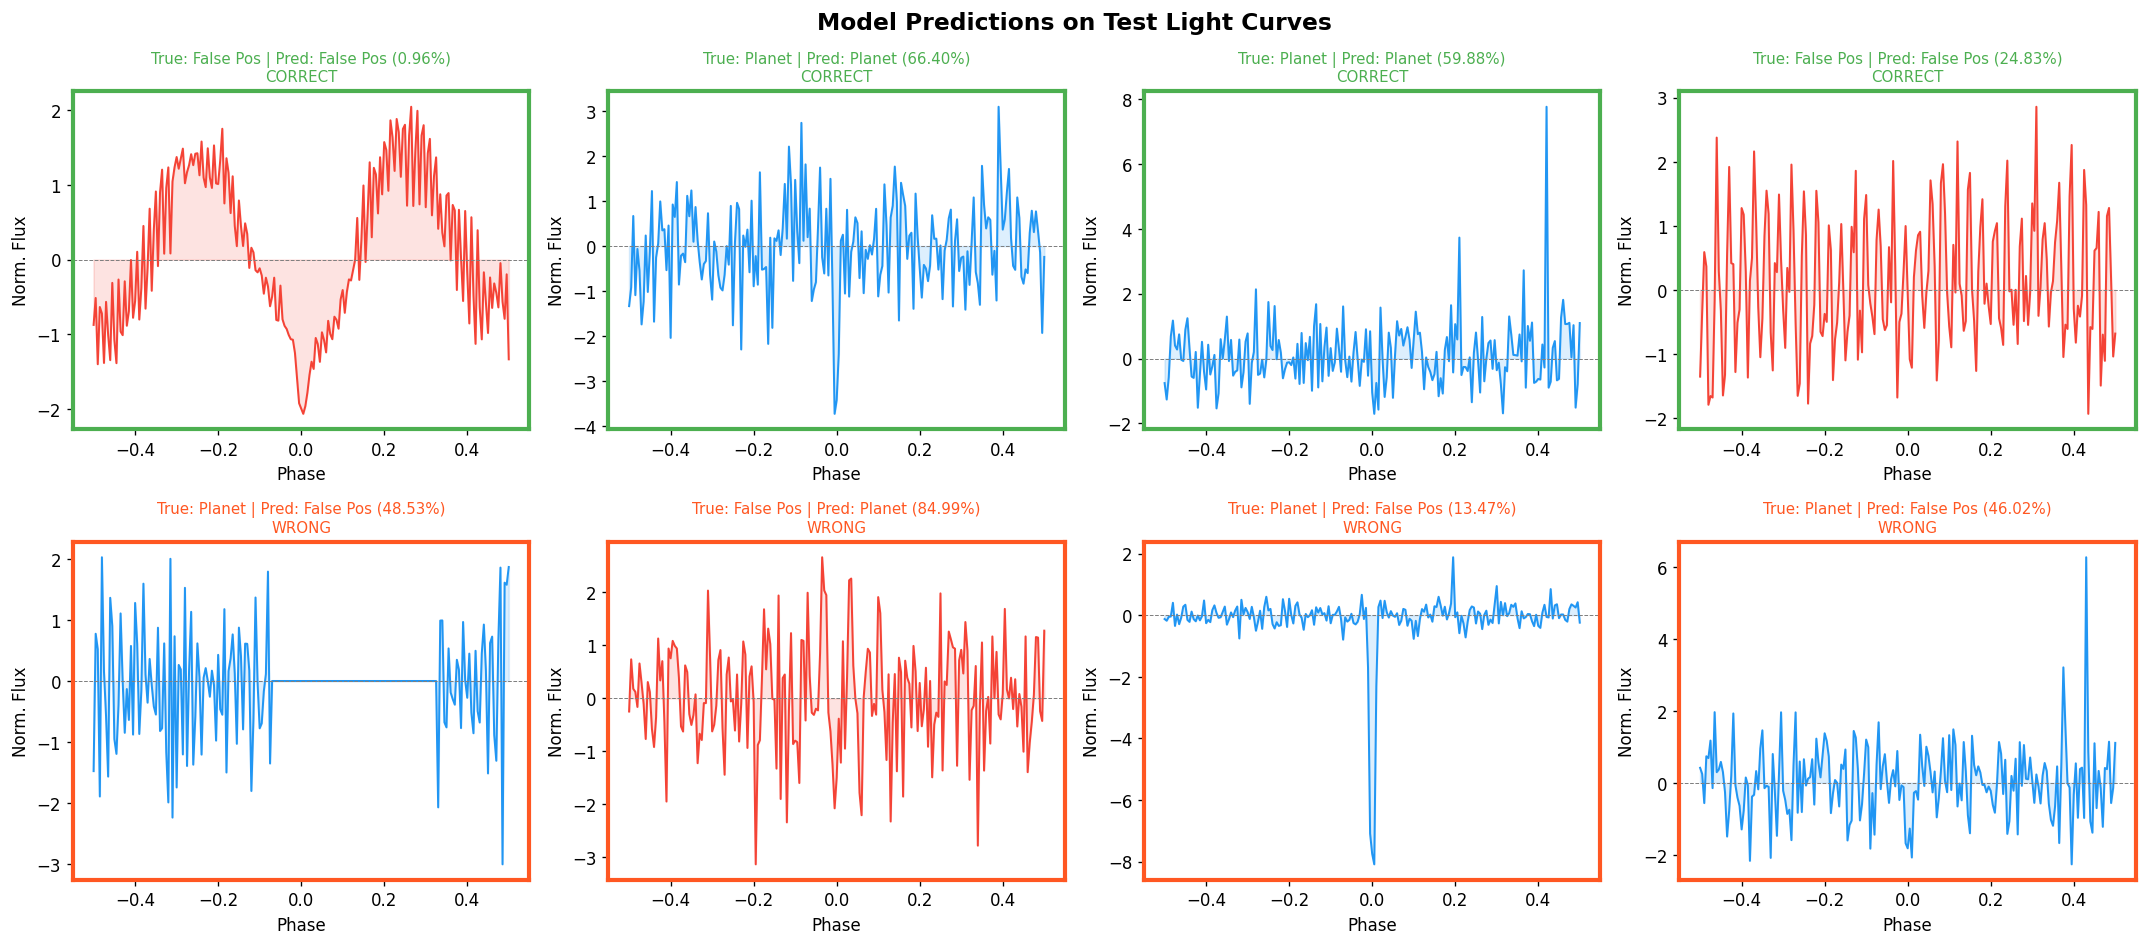


✅ Code Cell 15 Task Completed: Individual test predictions plotted and saved.


In [59]:
# --- Code Cell 15: Step 9 - Visualize Individual Predictions ---
import matplotlib.pyplot as plt
import numpy as np

# Create a figure with a 2x4 grid of subplots for visualizing individual predictions.
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Model Predictions on Test Light Curves', fontsize=14, fontweight='bold')

# Get indices of correctly and incorrectly classified samples from the test set.
correct_idx = np.where(y_pred == y_test)[0][:4] # Get first 4 correctly classified samples
wrong_idx   = np.where(y_pred != y_test)[0][:4] # Get first 4 incorrectly classified samples
# Combine these indices for visualization.
indices = list(correct_idx) + list(wrong_idx)
# Define the x-axis for the phase-folded light curves.
x_axis = np.linspace(-0.5, 0.5, BINS)

# Iterate through the selected indices and plot each light curve with its prediction.
for i, idx in enumerate(indices[:8]): # Visualize up to 8 examples
    ax = axes[i // 4][i % 4]
    # Extract flux, predicted probability, and determine if the prediction was correct.
    flux    = X_test[idx].flatten()
    prob    = y_prob[idx]
    correct = y_pred[idx] == y_test[idx]
    # Determine true and predicted labels for display.
    true_lbl = 'Planet'    if y_test[idx] == 1 else 'False Pos'
    pred_lbl = 'Planet'    if y_pred[idx] == 1 else 'False Pos'
    # Set color based on true label.
    color   = '#2196F3'    if y_test[idx] == 1 else '#F44336'
    # Set border color based on prediction correctness.
    border  = '#4CAF50'    if correct         else '#FF5722'

    # Plot the light curve.
    ax.plot(x_axis, flux, color=color, linewidth=1.2)
    # Fill the area under the curve.
    ax.fill_between(x_axis, flux, alpha=0.15, color=color)
    # Add a horizontal line at y=0.
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.6)
    # Highlight the subplot border based on correctness.
    for spine in ax.spines.values():
        spine.set_edgecolor(border)
        spine.set_linewidth(2.5)

    # Set the title with true label, predicted label, probability, and correctness status.
    status = 'CORRECT' if correct else 'WRONG'
    ax.set_title(f'True: {true_lbl} | Pred: {pred_lbl} ({prob:.2%})\n{status}', # Use .2% for percentage format
                 fontsize=9, color=border)
    ax.set_xlabel('Phase')
    ax.set_ylabel('Norm. Flux')

# Adjust layout to prevent titles and labels from overlapping.
plt.tight_layout()
# Save the figure to a file.
plt.savefig('predictions_examples.png', bbox_inches='tight')
# Display the plot.
plt.show()
print('\n✅ Code Cell 15 Task Completed: Individual test predictions plotted and saved.')

## 💾 Step 10: Save Model & Download All Outputs

In [60]:
# --- Code Cell 16: Step 10 - Save Model & Output to Google Drive ---
# Because we changed the working directory to Google Drive in Code Cell 1,
# all plots, CSVs, and numpy arrays have ALREADY been saved there automatically!

# We just need to save the final trained model:
model.save('exoplanet_cnn_model.keras')
print("✅ Model saved directly to Google Drive as 'exoplanet_cnn_model.keras'")

print(f"\n🎉 All data, generated plots, and models are safely backed up in your 'exoplanet_checkpoints' folder on Google Drive!")

✅ Model saved directly to Google Drive as 'exoplanet_cnn_model.keras'

🎉 All data, generated plots, and models are safely backed up in your 'exoplanet_checkpoints' folder on Google Drive!


## 🚀 (Optional) Step 11: Predict on Any Kepler Star

Change the values below to test any KOI.

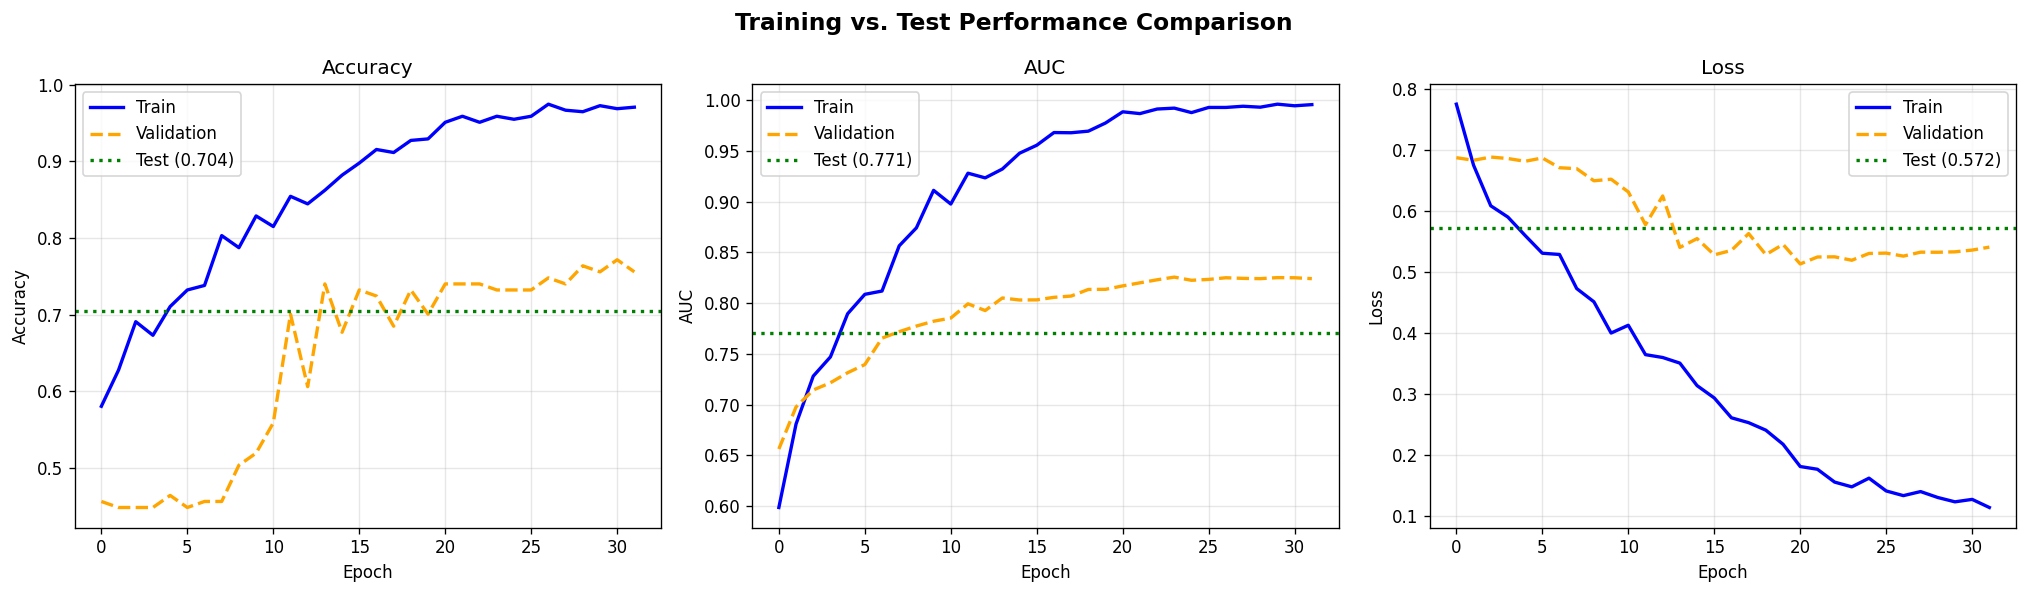


✅ Code Cell 17 Task Completed: Training vs Test performance plots successfully generated and saved.


In [61]:
# --- Code Cell 17: Step 11 - Training vs Test Performance ---
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Training vs. Test Performance Comparison', fontsize=14, fontweight='bold')

metrics_to_compare = ['accuracy', 'auc', 'loss']
metric_titles = ['Accuracy', 'AUC', 'Loss']

# Extract test metrics from the 'results' array
test_accuracy = results[1]
test_auc = results[2]
test_loss = results[0]

test_metrics = { 'accuracy': test_accuracy, 'auc': test_auc, 'loss': test_loss }

for i, (metric, title) in enumerate(zip(metrics_to_compare, metric_titles)):
    ax = axes[i]

    # Plot training and validation history
    ax.plot(history.history[metric], label='Train', linewidth=2, color='blue')
    ax.plot(history.history[f'val_{metric}'], label='Validation', linewidth=2, linestyle='--', color='orange')

    # Plot test metric as a horizontal line or point
    ax.axhline(test_metrics[metric], color='green', linestyle=':', linewidth=2, label=f'Test ({test_metrics[metric]:.3f})')

    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_test_comparison.png', bbox_inches='tight')
plt.show()
print('\n✅ Code Cell 17 Task Completed: Training vs Test performance plots successfully generated and saved.')

## 🌐 Step 12: Web Frontend with Gradio
Let's create a user interface where anyone can enter a Kepler ID and see the model's prediction in real-time.

In [62]:
# --- Code Cell 18: Step 12 - Web Frontend with Gradio (Install) ---
!pip install gradio -q

In [63]:
# --- Code Cell 19: Step 12 - Web Frontend with Gradio (App) ---
def predict_exoplanet(kepler_id, period, t0):
    # 1. Fetch and process the data
    flux = download_and_fold(int(kepler_id), float(period), float(t0))

    if flux is None:
        return "❌ Error: Could not download or process light curve. Please check the ID.", None

    # 2. Run the model prediction
    prob = model.predict(flux.reshape(1, BINS, 1), verbose=0)[0][0]
    verdict = '🪐 PLANET DETECTED' if prob >= 0.5 else '❌ FALSE POSITIVE'

    # 3. Generate the visualization
    fig, ax = plt.subplots(figsize=(8, 4))
    x_axis = np.linspace(-0.5, 0.5, BINS)
    color = '#2196F3' if prob >= 0.5 else '#F44336'

    ax.plot(x_axis, flux, color=color, linewidth=1.5)
    ax.fill_between(x_axis, flux, alpha=0.15, color=color)
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(f'KIC {int(kepler_id)}  —  Confidence: {prob:.1%}', fontsize=12)
    ax.set_xlabel('Phase')
    ax.set_ylabel('Normalized Flux')
    plt.tight_layout()

    return f"{verdict} (Confidence: {prob:.1%})", fig

# Custom CSS for the sky blue to space purple scroll effect
custom_css = """
.gradio-container {
    background: linear-gradient(180deg, #87CEEB 0%, #4B0082 60%, #1a0033 100%) !important;
    background-attachment: fixed !important;
    min-height: 100vh;
}
.gradio-container * {
    /* Make text readable against the dark space background where necessary */
}
"""

# Create the Gradio interface
demo = gr.Interface(
    fn=predict_exoplanet,
    inputs=[
        gr.Number(label="Kepler ID (e.g., 11442793)", value=11442793),
        gr.Number(label="Period in days (e.g., 14.449)", value=14.44912),
        gr.Number(label="T0 / Epoch (e.g., 2.2)", value=2.2)
    ],
    outputs=[
        gr.Textbox(label="Model Prediction"),
        gr.Plot(label="Light Curve Analysis")
    ],
    title="🪐 Exoplanet CNN Detector",
    description="Enter the parameters of a Kepler Object of Interest (KOI). The app will download the light curve from NASA MAST, fold it, and use the trained 1D CNN to predict if it's an exoplanet.",
    examples=[
        [11442793, 14.44912, 2.2],  # Kepler-90g (Confirmed)
        [3544595, 4.88780, 0.5],    # Kepler-42b (Confirmed)
        [9941662, 4.9278, 1.2],     # KOI-189 (False Positive)
        [5358624, 3.521, 0.3]       # KOI-203 (False Positive)
    ],
    css=custom_css
)

# Launch the web app (this will provide a public link you can share!)
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fcba2ae01871ab4658.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
